# ChurnShield — Exploratory Data Analysis

**Author:** Ulrich David TASSEMBEDO 
**Date:** April 2026  
**Dataset:** [Telco Customer Churn — IBM Watson](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Objective:** Understand the data, identify key churn drivers, and prepare features for ML modeling.


## 1. Setup & Libraries

Importing the necessary libraries for data manipulation, statistical analysis and visualization.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print ("Libraries loaded successfully")

Libraries loaded successfully


## 2. Data Loading

Loading the raw dataset from the 'data/raw/' directory.
The dataset contains information about Telco customers and whether they churned or not.

In [12]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset loaded - shape: {df.shape}")
print(df.head())

Dataset loaded - shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0  

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
misssing = df.isnull().sum()
misssing_pct = (df.isnull().sum()/len(df) *100)
misssing_df = pd.DataFrame({
    "Missing Values" : misssing,
    "Percentage(%)": misssing_pct.round(2)
})
print(misssing_df[misssing_df["Missing Values"]>0])
print("No missing values " if misssing.sum() == 0 else "Missing values detected")

Empty DataFrame
Columns: [Missing Values, Percentage(%)]
Index: []
No missing values 


## 3. Data Quality Check

- 'TotalCharges' was stored as 'string' instead of 'float' due to empty spaces - converted to numeric.
- **11 rows** with empty 'TotalCharges' were dropped (0.15% of data - negligible).
- No other missing values detected.

In [16]:
print("=== TotalCharges : abnormal unique values ===")
problematic = df[df["TotalCharges"].str.strip() == ""]
print(f"Number of rows with empty TotalCharges : {len(problematic)}")
print(problematic[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

=== TotalCharges : abnormal unique values ===
Number of rows with empty TotalCharges : 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


## 4. Target Variable Analysis

Analyzing the distribution of our target variable 'Churn'.

**Key findings:**
- **73.4%** of customers did not churn → majority class
- **26.6%** of customers churned → minority class
- The dataset is moderately imbalanced — we will use 'class_weight='balanced''
and optimize for **F1-Score** rather than accuracy during modeling.

In [17]:
print("=== Distribution of the target variable : Churn ===")
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True)*100
churn_summary = pd.DataFrame({
    "count" : churn_counts,
    "Percentage(%)" : churn_pct
})
print( churn_summary)

=== Distribution of the target variable : Churn ===
       count  Percentage(%)
Churn                      
No      5174      73.463013
Yes     1869      26.536987


In [18]:
# Convert TotalCharges to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

print(df[df["TotalCharges"].isna()][["TotalCharges"]])
#Drop rows here TotalCharges is NaN (the 11 empty rows)
df = df.dropna(subset=['TotalCharges'])
# Verify fix
print(f" TotalCharges dtype : {df['TotalCharges'].dtype}")
print(f" Remaining rows     : {len(df)}")
print(f" Missing values     : {df['TotalCharges'].isnull().sum()}")

      TotalCharges
488            NaN
753            NaN
936            NaN
1082           NaN
1340           NaN
3331           NaN
3826           NaN
4380           NaN
5218           NaN
6670           NaN
6754           NaN
 TotalCharges dtype : float64
 Remaining rows     : 7032
 Missing values     : 0


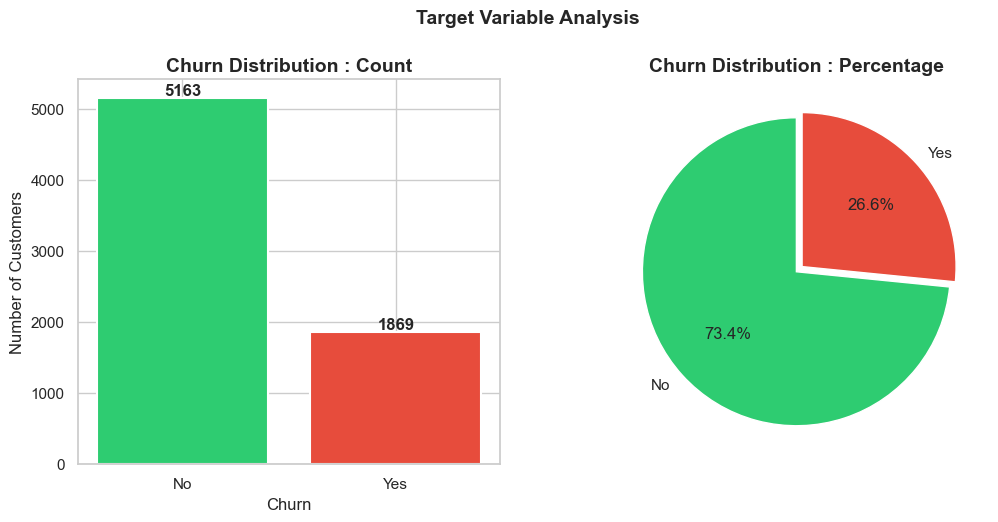

 Plot saved


In [19]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# ---- Left : Count plot ----
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor = "white", linewidth = 1.5)
axes[0].set_title('Churn Distribution : Count', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')
    
# ---- Right : Pie chart ----
axes[1].pie(churn_counts.values,
            labels = churn_counts.index,
            autopct = '%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle = 90,
            explode =(0, 0.05))
axes[1].set_title('Churn Distribution : Percentage', fontsize = 14, fontweight = 'bold')
plt.suptitle('Target Variable Analysis', fontsize = 14, fontweight = 'bold', y=1.02)

plt.savefig('../data/processed/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved")

## 5. Numerical Features Analysis

Analyzing the 3 numerical features: 'tenure', 'MonthlyCharges', 'TotalCharges'.

**Key findings:**
- **tenure** : Customers who churn have a median tenure of ~10 months vs ~38 months for loyal customers.
Early churn is the main pattern — retention efforts should focus on the **first 12 months**.
- **MonthlyCharges** : Churners pay ~80$/month vs ~63$ for loyal customers.
High bills → lower perceived value → higher churn risk.
- **TotalCharges** : Strongly correlated with `tenure` (multicollinearity risk).
Will be monitored during feature selection.

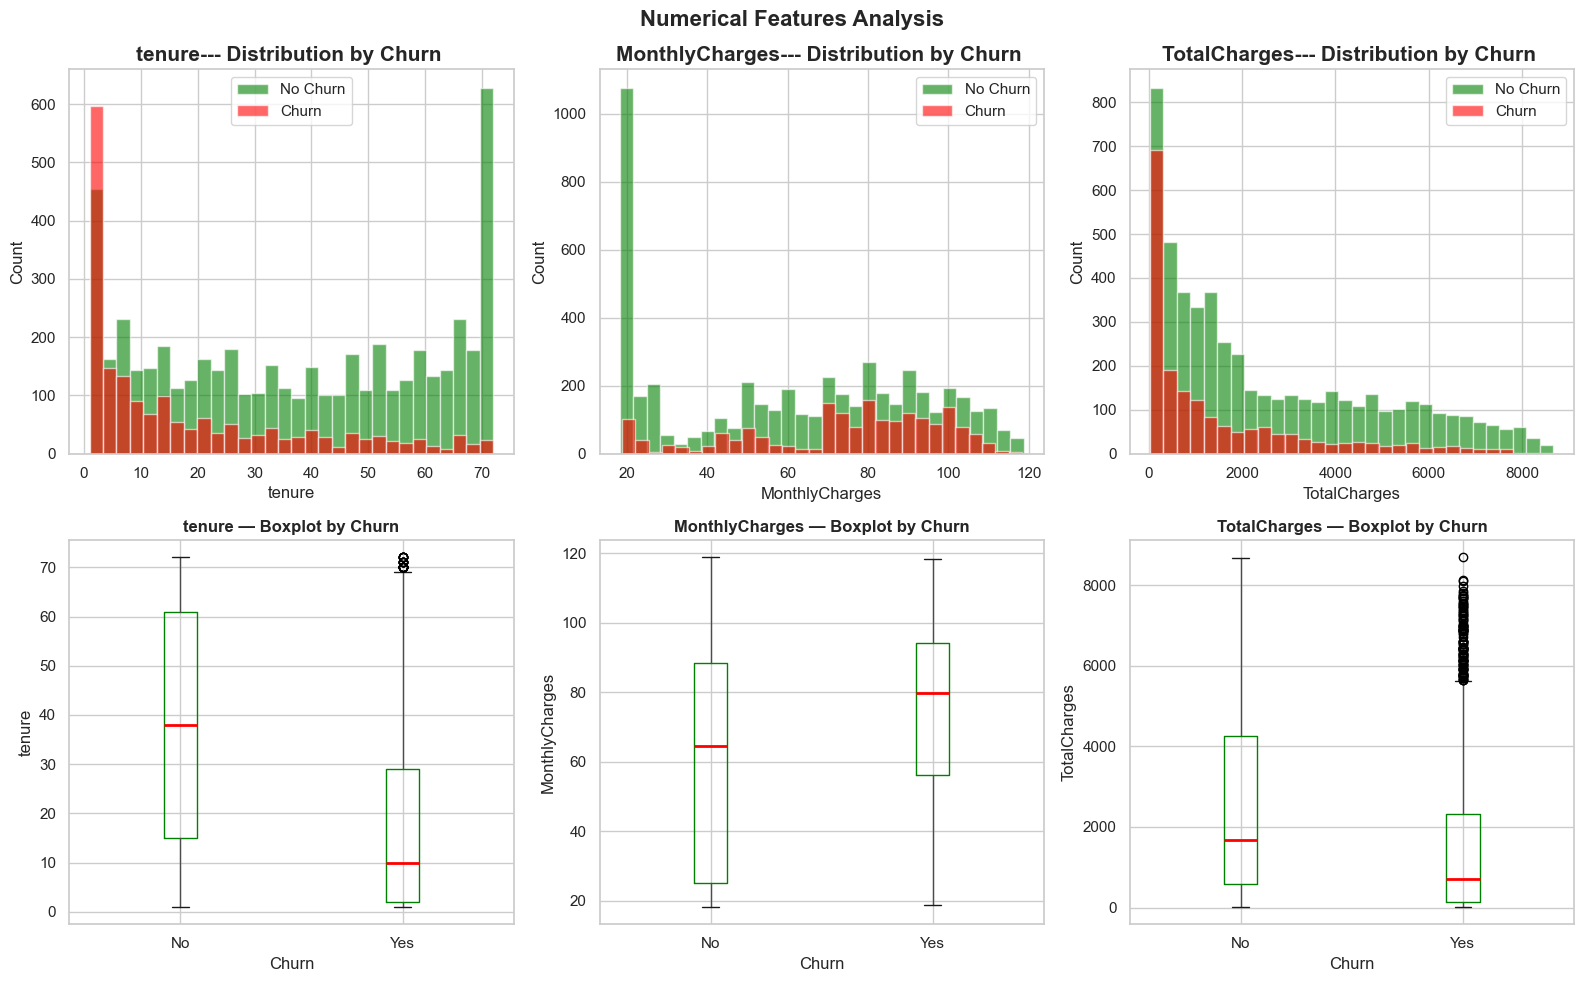

✅ Plot saved


In [20]:
numerical_cols = ['tenure','MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize = (16, 10))

for i, col in enumerate(numerical_cols):
    
    # --- Row 1 : Distribution by Churn ---
    df[df['Churn'] == 'No'][col].hist(ax =axes[0,i], bins =30, alpha=0.6, color = 'green', label = 'No Churn')
    df[df['Churn'] == 'Yes'][col].hist(ax=axes[0,i], bins = 30, alpha = 0.6, color = 'red', label = 'Churn')
    axes[0, i].set_title(f"{col}--- Distribution by Churn ", fontsize=15, fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].legend()
    
    # --- Row 2 : Boxplot ---
    df.boxplot(ax=axes[1, i], by='Churn', column=col, 
               boxprops=dict(color='green'), medianprops=dict(color='red', linewidth  = 2))
    axes[1, i].set_title(f'{col} — Boxplot by Churn', fontweight='bold')
    axes[1, i].set_xlabel('Churn')
    axes[1, i].set_ylabel(col)

plt.suptitle('Numerical Features Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/numerical_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

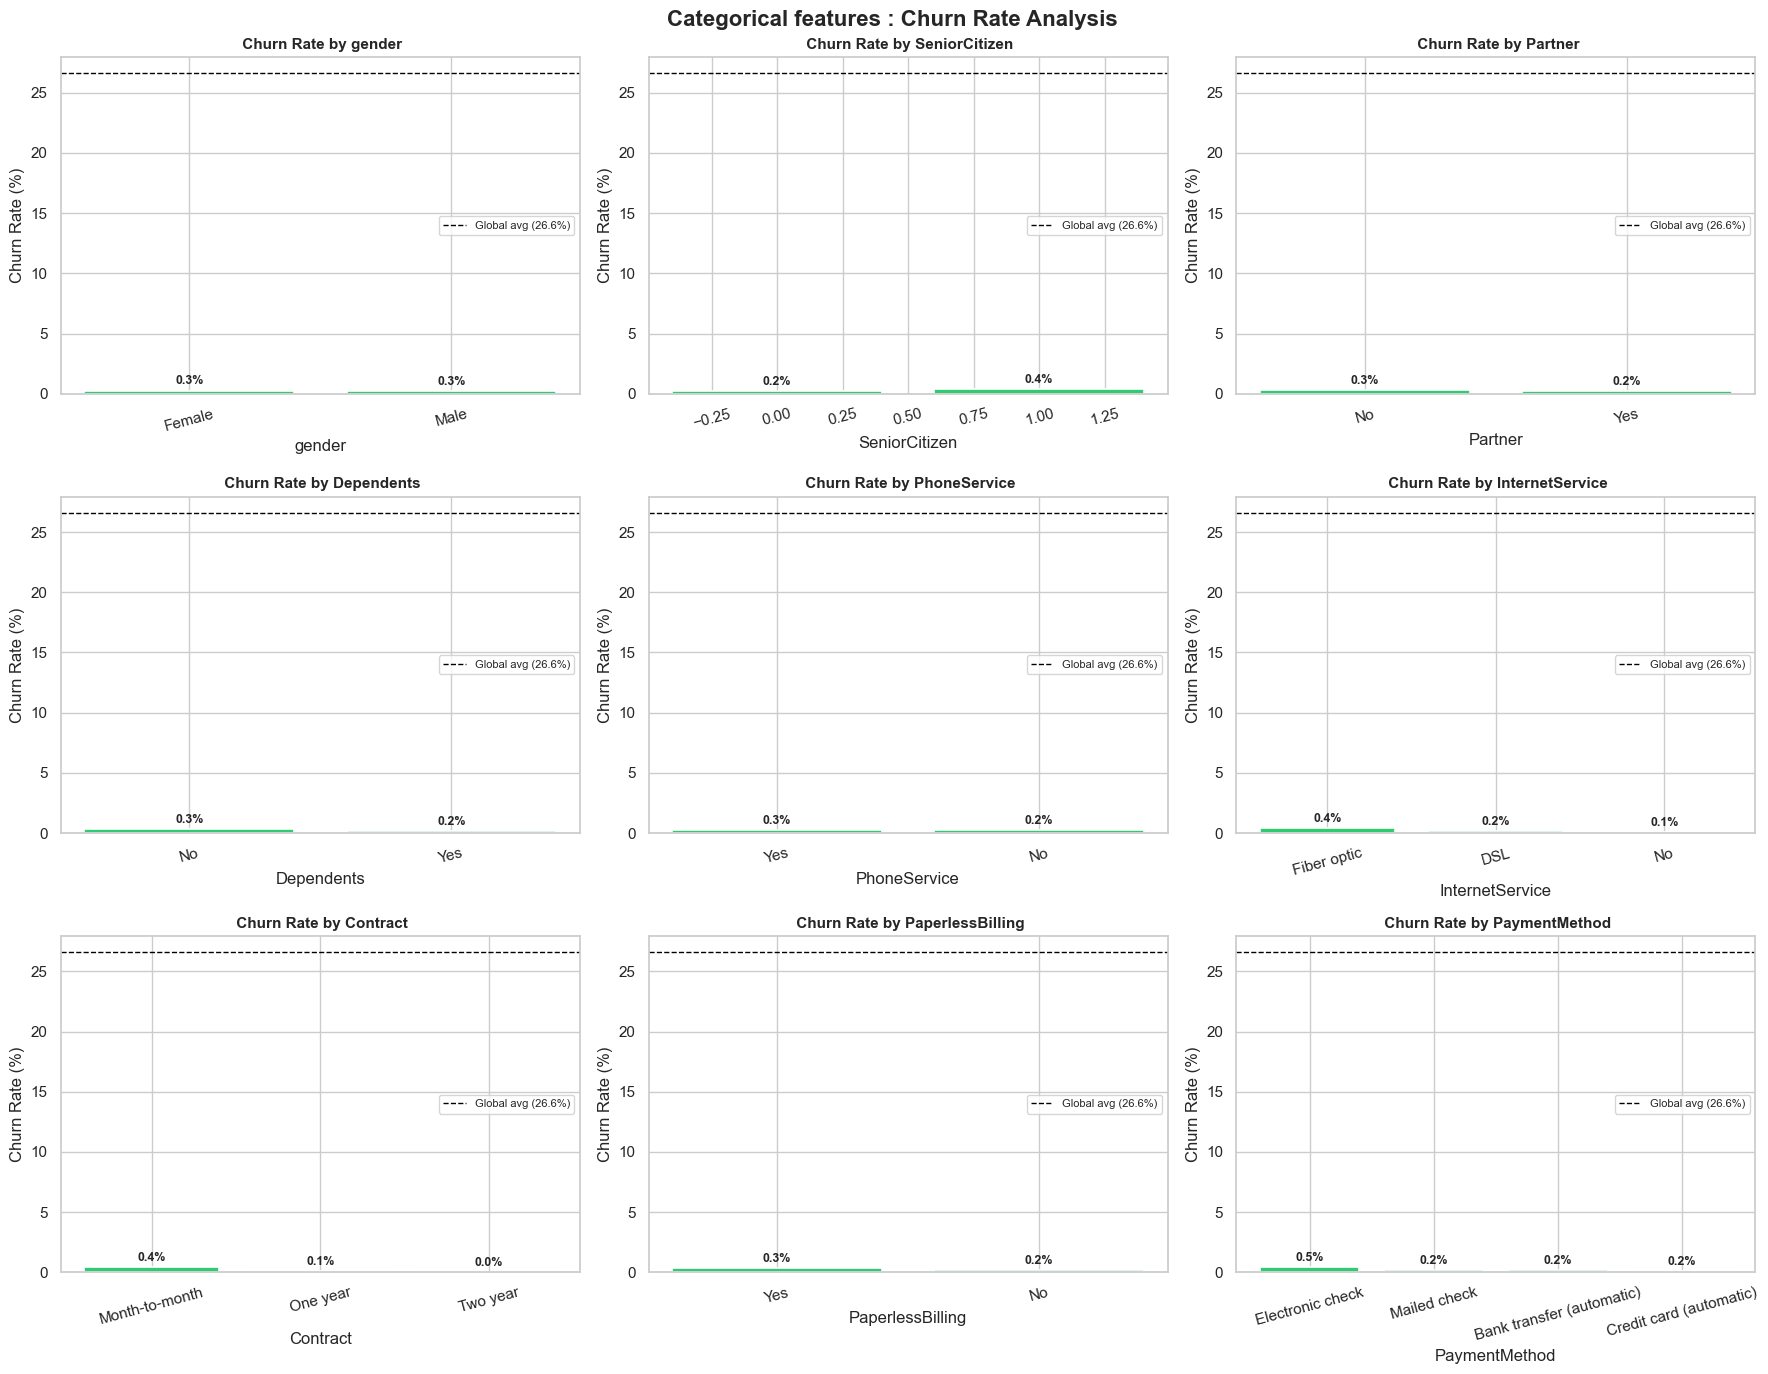

✅ Plot saved


In [ ]:
# Categorical columns to analyze
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'InternetService', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x : (x=='Yes').sum()/len(x)*100
    ).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)
    bars = axes[i].bar(
        churn_rate[col],
        churn_rate['ChurnRate'],
        color=['#e74c3c' if x > 26.6 else '#2ecc71' for x in churn_rate['ChurnRate']],
        edgecolor='white', linewidth=1.2
    )
    
    # Add percentage labels on bars
    for bar, val in zip(bars, churn_rate['ChurnRate']):
        axes[i].text(
            bar.get_x()+ bar.get_width()/2,
            bar.get_height()+0.5,
            f'{val:.1f}%',
            ha = 'center',
            fontsize = 9,
            fontweight = 'bold'
        )
    axes[i].axhline(y=26.6, linestyle ='--', color='black',
                    linewidth=1, label = 'Global avg (26.6%)')
    axes[i].set_title(f' Churn Rate by {col}', fontweight = 'bold', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=15)
plt.suptitle('Categorical features : Churn Rate Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/categorical_features.png', dpi = 150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

   